In [1]:
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
ibd_path = "lwk.refined_ibd.merged.ibd.gz"

# approximate autosomal genome size
total_autosomal_bp = 2_870_000_000

In [3]:
def canonical_pair(iid1, iid2):
    return (iid1, iid2) if iid1 <= iid2 else (iid2, iid1)

In [4]:
def read_refined_ibd_segments(
    ibd_path,
    chrom_min=1,
    chrom_max=22,
    min_lod=None,
    min_bp=None
):

    rows = []

    with gzip.open(ibd_path, "rt") as f:
        for line in f:

            if not line.strip():
                continue

            parts = line.split()
            if len(parts) < 8:
                continue

            id1, h1, id2, h2, chrom, start, end, lod = parts[:8]

            chrom = int(chrom)
            if chrom < chrom_min or chrom > chrom_max:
                continue

            s = int(start)
            e = int(end)

            if e < s:
                s, e = e, s

            seg_len = e - s + 1

            if min_bp is not None and seg_len < min_bp:
                continue

            lod = float(lod)

            if min_lod is not None and lod < min_lod:
                continue

            iid1 = id1.split("_")[0]
            iid2 = id2.split("_")[0]

            A, B = canonical_pair(iid1, iid2)

            rows.append({
                "A":A,
                "B":B,
                "chrom":chrom,
                "start":s,
                "end":e,
                "lod":lod
            })

    return rows

In [5]:
def merge_intervals(intervals):

    if not intervals:
        return []

    intervals = sorted(intervals)

    merged = [list(intervals[0])]

    for s,e in intervals[1:]:

        if s <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], e)

        else:
            merged.append([s,e])

    return [(s,e) for s,e in merged]

In [6]:
def summarize_pairs(segments, total_autosomal_bp):

    pair_chrom_intervals = defaultdict(lambda: defaultdict(list))
    pair_raw_lens = defaultdict(list)
    pair_lods = defaultdict(list)

    for r in segments:

        A,B = r["A"], r["B"]
        chrom = r["chrom"]
        s,e = r["start"], r["end"]

        pair_chrom_intervals[(A,B)][chrom].append((s,e))
        pair_raw_lens[(A,B)].append(e-s+1)
        pair_lods[(A,B)].append(r["lod"])

    rows = []

    for (A,B), chrom_dict in pair_chrom_intervals.items():

        raw_lens = pair_raw_lens[(A,B)]

        merged_bp = 0

        for chrom, intervals in chrom_dict.items():

            merged = merge_intervals(intervals)
            merged_bp += sum(e-s+1 for s,e in merged)

        total_bp_raw = sum(raw_lens)
        total_mb_merged = merged_bp / 1e6

        rows.append({

            "A":A,
            "B":B,

            "nseg_raw":len(raw_lens),

            "total_bp_raw":total_bp_raw,
            "total_bp_merged":merged_bp,

            "total_mb_merged":total_mb_merged,

            "mean_seg_mb_raw":(total_bp_raw/len(raw_lens))/1e6 if raw_lens else 0,
            "max_seg_mb_raw":max(raw_lens)/1e6 if raw_lens else 0,

            "mean_lod":np.mean(pair_lods[(A,B)]),
            "max_lod":np.max(pair_lods[(A,B)]),

            "pihat_like":(total_mb_merged/2)/3400
        })

    df = pd.DataFrame(rows)

    return df.sort_values(
        ["total_mb_merged","nseg_raw"],
        ascending=False
    ).reset_index(drop=True)

In [7]:
lod_thresholds = [None,1,3,5]
length_thresholds_mb = [0,1,3,5]

length_thresholds_bp = [x*1_000_000 for x in length_thresholds_mb]

In [8]:
results = []

for lod in lod_thresholds:

    for min_bp in length_thresholds_bp:

        segs = read_refined_ibd_segments(
            ibd_path,
            min_lod=lod,
            min_bp=min_bp
        )

        stats = summarize_pairs(segs, total_autosomal_bp)

        results.append({

            "lod":lod,
            "min_seg_mb":min_bp/1e6,

            "pairs_detected":len(stats),

            "max_shared_mb":stats["total_mb_merged"].max(),
            "mean_shared_mb":stats["total_mb_merged"].mean()
        })

threshold_summary = pd.DataFrame(results)

threshold_summary

,lod,min_seg_mb,pairs_detected,max_shared_mb,mean_shared_mb
0,NaN,0.0,4655,1468.666390,24.911134
1,NaN,1.0,4651,1439.562281,22.428259
2,NaN,3.0,3239,1259.775429,15.244563
3,NaN,5.0,1356,1107.471684,21.476307
4,1.0,0.0,4655,1468.666390,24.911134
5,1.0,1.0,4651,1439.562281,22.428259
6,1.0,3.0,3239,1259.775429,15.244563
7,1.0,5.0,1356,1107.471684,21.476307
8,3.0,0.0,4655,1468.666390,24.911134
9,3.0,1.0,4651,1439.562281,22.428259


In [9]:
segs = read_refined_ibd_segments(
    ibd_path,
    min_lod=3,
    min_bp=3_000_000
)

pair_stats = summarize_pairs(segs, total_autosomal_bp)

pair_stats.head(30)

,A,B,nseg_raw,total_bp_raw,total_bp_merged,total_mb_merged,mean_seg_mb_raw,max_seg_mb_raw,mean_lod,max_lod,pihat_like
0,NA19396,NA19397,114,1259775429,1259775429,1259.775429,11.050662,66.132712,111.816842,573.88,0.185261
1,NA19443,NA19470,102,1197398437,1197398437,1197.398437,11.739200,63.045315,96.790294,549.75,0.176088
2,NA19331,NA19334,93,1178548475,1178548475,1178.548475,12.672564,96.961685,108.170753,737.19,0.173316
3,NA19434,NA19444,103,1144127297,1144127297,1144.127297,11.108032,61.296844,102.542524,698.20,0.168254
4,NA19347,NA19352,86,1139293590,1139293590,1139.293590,13.247600,97.266672,95.749419,419.16,0.167543
5,NA19373,NA19374,78,1071737912,1071737912,1071.737912,13.740230,57.460843,147.980000,673.70,0.157609
6,NA19381,NA19382,142,928973387,928973387,928.973387,6.542066,31.558513,38.473451,108.47,0.136614
7,NA19445,NA19453,139,871707255,871707255,871.707255,6.271275,22.778724,39.662230,136.34,0.128192
8,NA19313,NA19331,133,837874546,837874546,837.874546,6.299809,28.836875,35.135714,96.60,0.123217
9,NA19469,NA19470,132,833894570,833894570,833.894570,6.317383,26.567734,35.239167,118.43,0.122632


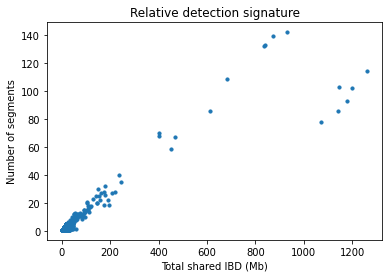

In [10]:
plt.figure()

plt.scatter(
    pair_stats["total_mb_merged"],
    pair_stats["nseg_raw"],
    s=10
)

plt.xlabel("Total shared IBD (Mb)")
plt.ylabel("Number of segments")

plt.title("Relative detection signature")

plt.show()

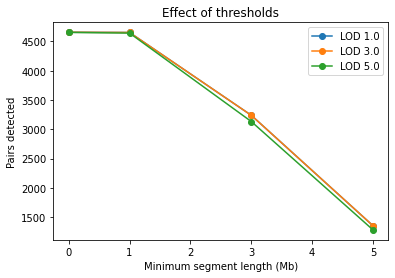

In [11]:
plt.figure()

for lod in sorted(threshold_summary["lod"].dropna().unique()):

    subset = threshold_summary[threshold_summary["lod"]==lod]

    plt.plot(
        subset["min_seg_mb"],
        subset["pairs_detected"],
        marker="o",
        label=f"LOD {lod}"
    )

plt.xlabel("Minimum segment length (Mb)")
plt.ylabel("Pairs detected")

plt.title("Effect of thresholds")

plt.legend()

plt.show()